Submitted by Group 11:

- Ehsan Attar
- Reihaneh Akbarifard
- Maryam Poorsalman Ahvazi
- Ramin Shahbazi

By submitting this exercise, you confirm the following:

- **All people** listed above **contributed** to this solution
- **No other people** were **involved** in this solution
- **No contents** of this solution were **copied from others** (this includes people, large language models, websites, etc.)

In [1]:
import os
import cv2
import numpy as np
from skimage import exposure
from skimage import data, img_as_float
import matplotlib.pyplot as plt
np.random.seed(42)
H, W = 256, 256 # Image dimensions

## Helper Functions

In [2]:
def read_image(filename, format='gray'):
    """
    Read image from file and convert to specified format.
    """
    basepath = os.path.curdir
    img = cv2.imread(os.path.join(basepath, 'data', 'input', filename))
    if format == 'gray':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    elif format == 'rgb':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    return img.astype(np.float64)

In [3]:
def plot_1d(signals, labels=None, title=None, xlabel='Pixel', ylabel='Intensity', figsize=(10, 3.5)):
    labels = list(labels or []) + [f"Signal {i+1}" for i in range(len(labels or []), len(signals))]
    fig, ax = plt.subplots(figsize=figsize)
    for signal, label in zip(signals, labels):
        ax.plot(signal, label=label, linewidth=1.5)
    ax.set_title(title or '', fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return fig, ax

In [4]:
def sift_match(
    img1: np.ndarray,
    img2: np.ndarray,
    ratio: float = 0.8,
):
    """
    Detect SIFT keypoints on two images, match with BFMatcher, and apply Lowe's ratio test.

    Returns
    -------
    kp1, kp2   : keypoint lists
    good       : DMatch list surviving the ratio test
    match_img  : visualisation of good matches (BGR)
    """
    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    bf   = cv2.BFMatcher(cv2.NORM_L2)
    raw  = bf.knnMatch(des1, des2, k=2)
    good = [m for m, n in raw if m.distance / n.distance < ratio]

    match_img = cv2.drawMatches(
        img1, kp1, img2, kp2, good, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    return kp1, kp2, good, match_img

In [5]:
def plot_img_and_hist(image, axes, bins=256):
    """Plot an image along with its histogram and cumulative histogram."""

    image = img_as_float(image)
    ax_img, ax_hist = axes
    ax_cdf = ax_hist.twinx()

    # Display image
    ax_img.imshow(image, cmap=plt.cm.gray)
    ax_img.set_axis_off()

    # Display histogram
    ax_hist.hist(image.ravel(), bins=bins, histtype='step', color='black')
    ax_hist.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    ax_hist.set_xlabel('Pixel intensity')
    ax_hist.set_xlim(0, 1)
    ax_hist.set_yticks([])

    # Display cumulative distribution
    img_cdf, bins = exposure.cumulative_distribution(image, bins)
    ax_cdf.plot(bins, img_cdf, 'r')
    ax_cdf.set_yticks([])

    return ax_img, ax_hist, ax_cdf

## Question 1: SIFT and Feature Matching

### (1a) Detecting and visualising SIFT keypoints

1. Create a SIFT detector with `cv2.SIFT_create()` and run `.detectAndCompute()` on your image. Draw keypoints using `cv2.drawKeypoints()` with `cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS`- this renders each keypoint as a circle whose radius encodes scale and whose line encodes dominant orientation.

2. Extract three properties from the keypoint list — `kp.size` (scale), `kp.angle` (orientation 0-360°), and `kp.response` (detection strength), and plot their distributions as histograms. 

3. What is the dominant scale of detected keypoints? Are orientations roughly uniformly distributed, or do they cluster around certain directions? What does a non-uniform orientation distribution tell you about the image content?

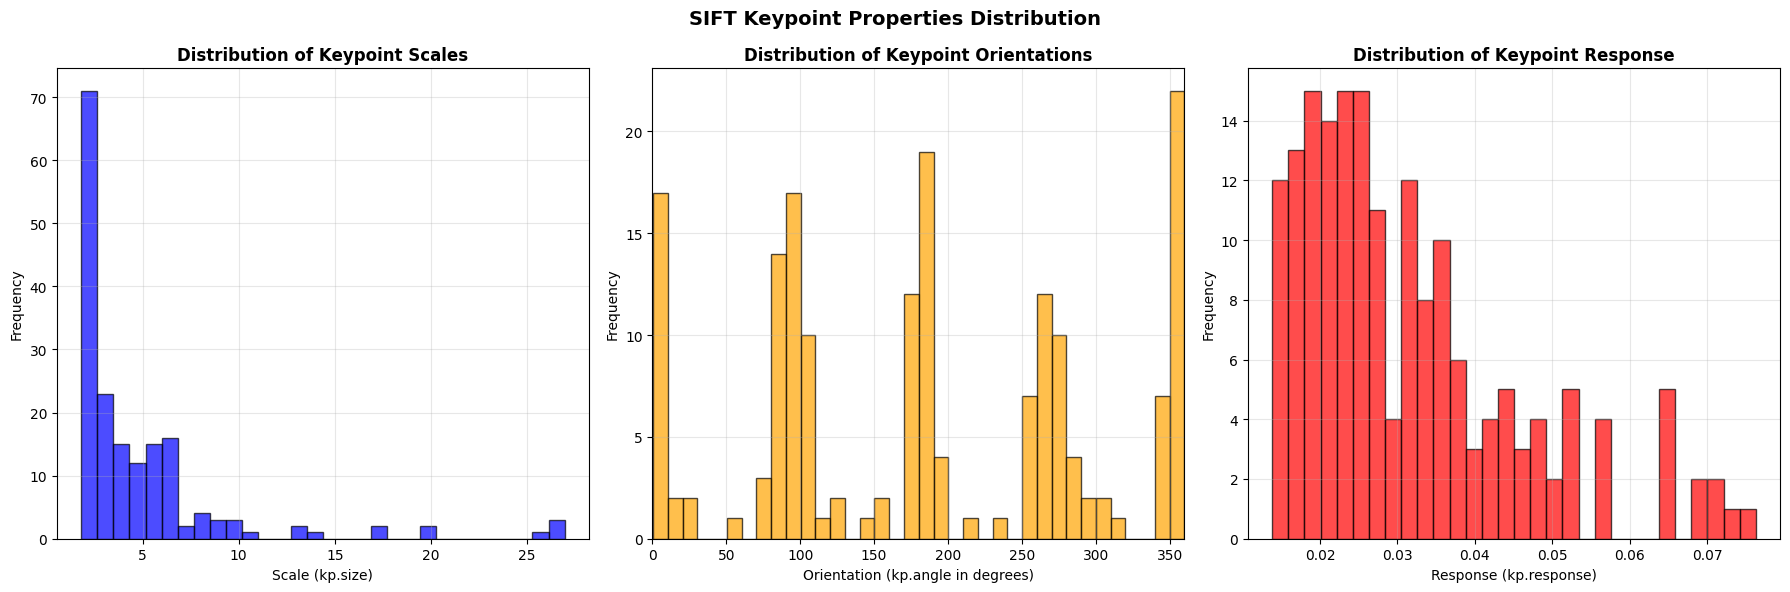

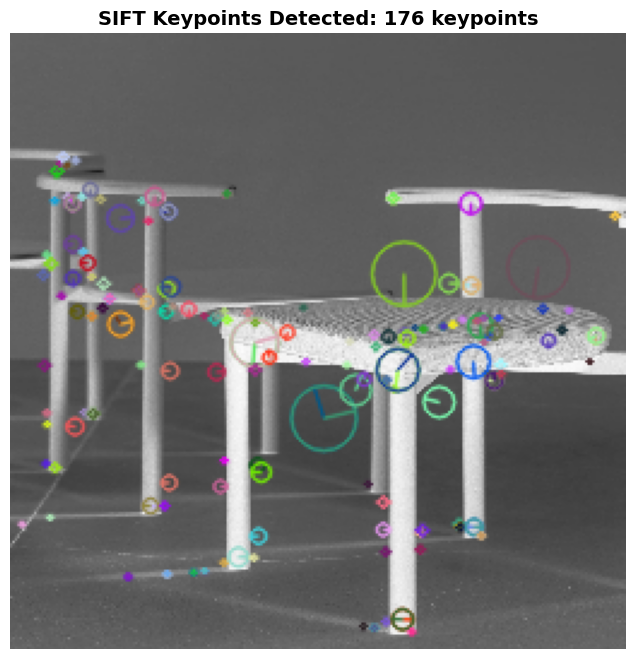

In [6]:
img_original = read_image('pexels-cottonbro-6627112.jpg', format='rgb')
img_original = (img_original * 255).astype(np.uint8)

img_gray = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)

sift = cv2.SIFT_create()
kp, descriptors = sift.detectAndCompute(img_gray, None)

img_gray_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

img_with_keypoints = cv2.drawKeypoints(
    img_gray,
    kp,
    img_gray_rgb.copy(),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

cv2.imwrite('data/output/image-with-keypoints.jpg',
            cv2.cvtColor(img_with_keypoints, cv2.COLOR_RGB2BGR))

scales = np.array([kp_point.size for kp_point in kp])
orientations = np.array([kp_point.angle for kp_point in kp])
responses = np.array([kp_point.response for kp_point in kp])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Scale Distribution
axes[0].hist(scales, bins=30, color='blue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Keypoint Scales', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Scale (kp.size)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Orientation Distribution
axes[1].hist(orientations, bins=36, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Keypoint Orientations', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Orientation (kp.angle in degrees)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 360)
axes[1].grid(True, alpha=0.3)

# Response Distribution
axes[2].hist(responses, bins=30, color='red', edgecolor='black', alpha=0.7)
axes[2].set_title('Distribution of Keypoint Response', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Response (kp.response)')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.suptitle('SIFT Keypoint Properties Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Display the image with keypoints
plt.figure(figsize=(10, 8))
plt.imshow(img_with_keypoints)
plt.title(f'SIFT Keypoints Detected: {len(kp)} keypoints', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

**Dominant Scale:** The keypoints show a dominant scale around 1.8-3.0, indicating the image contains primarily fine-scale features like texture details and thin edge structures.

**Orientation Distribution:** Orientations are NOT uniformly distributed. They cluster around ~90° (vertical) and ~180° (horizontal) directions, with secondary peaks around ~270° and ~0°.

**Image Content Interpretation:** The non-uniform orientation distribution indicates structured, geometric content rather than natural textures. The clustering around vertical and horizontal directions suggests man-made objects with clear geometric structure - consistent with furniture (chair legs, seat edges, backrest) and architectural elements. This pattern is typical of indoor scenes containing manufactured objects with dominant edge orientations.

### (1b) Brute-force matching and Lowe's ratio test

1. Use the provided `sift_match()` helper to match SIFT features between two images of the same scene (for example 2 different views of a scene or with a flipped version of original). Internally it runs `cv2.BFMatcher()` with knnMatch(k=2) and applies Lowe's ratio test at threshold $t=0.80$. 

2. Visualize the matches before and after the ratio test using `cv2.drawMatches()`. Report total raw matches, matches surviving the ratio test, and the rejection rate as a percentage. Now sweep the ratio threshold $t \in \{0.5, 0.6, 0.7, 0.9, 1.0\}$. Report surviving match count for each. Plot match count vs t using `plot_1d()`.

3. What does the ratio test actually check? At what threshold do you get a good balance between keeping correct matches and rejecting false ones on your image pair? Which performs the worst and why?

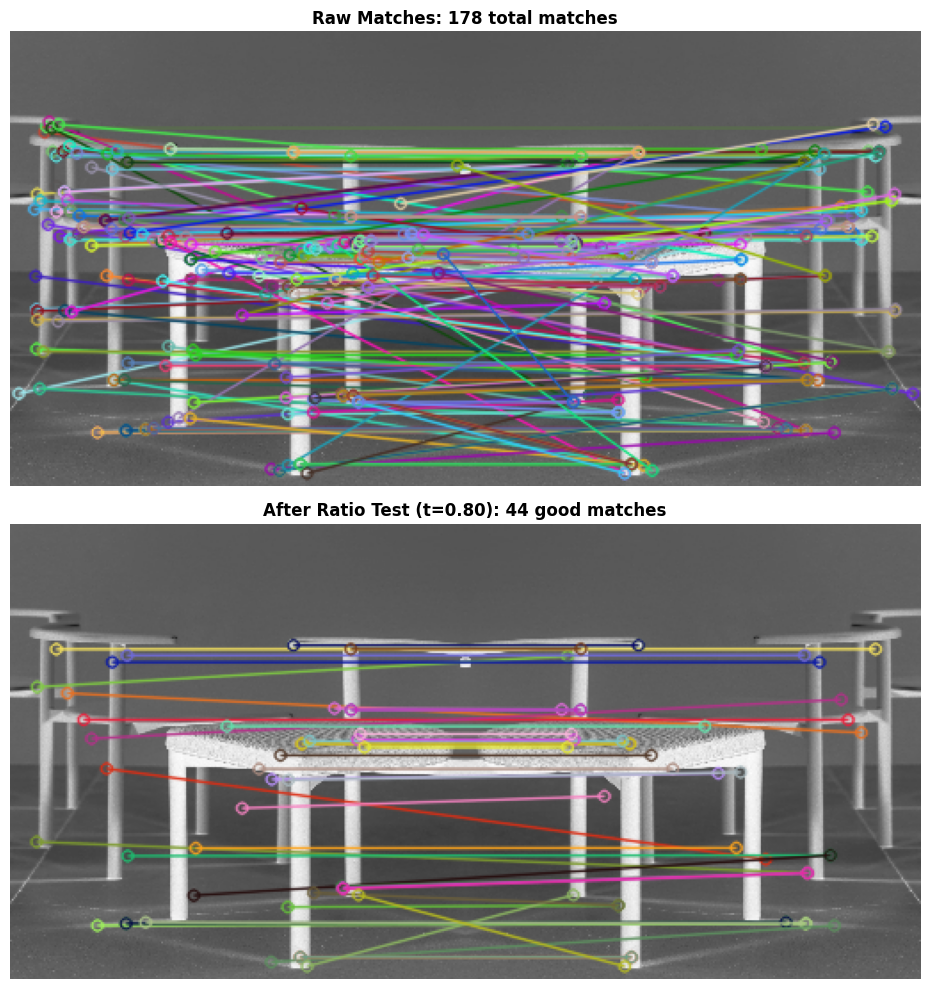

Total raw matches: 178
Matches after ratio test (t=0.80): 44
Rejection rate: 75.3%
Ratio t=0.5: 8 matches
Ratio t=0.6: 11 matches
Ratio t=0.7: 18 matches
Ratio t=0.8: 44 matches
Ratio t=0.9: 84 matches
Ratio t=1.0: 178 matches


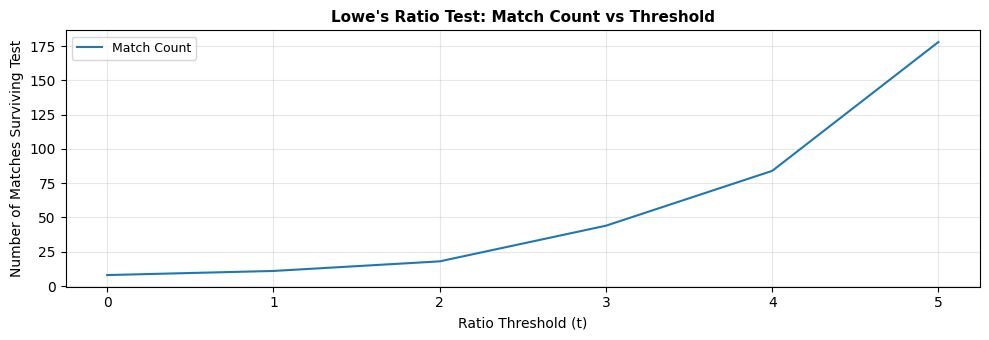

In [7]:
img1 = read_image('pexels-cottonbro-6627112.jpg', format='gray')
img1 = (img1 * 255).astype(np.uint8)
img2 = cv2.flip(img1, 1)

kp1, kp2, good, match_img = sift_match(img1, img2, ratio=0.8)

# without ratio test
sift = cv2.SIFT_create()
kp1_all, des1 = sift.detectAndCompute(img1, None)
kp2_all, des2 = sift.detectAndCompute(img2, None)

# Check if descriptors are valid
if des1 is None or des2 is None:
    print("Error: No descriptors found in one or both images")
else:
    bf = cv2.BFMatcher(cv2.NORM_L2)
    raw_matches = bf.knnMatch(des1, des2, k=2)

    # Filter out matches that don't have 2 neighbors
    raw_matches = [m for m in raw_matches if len(m) == 2]
    raw_matches_list = [m for m, n in raw_matches]

    # Draw all raw matches
    raw_match_img = cv2.drawMatches(
        img1, kp1_all,
        img2, kp2_all,
        raw_matches_list,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    axes[0].imshow(cv2.cvtColor(raw_match_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Raw Matches: {len(raw_matches)} total matches', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'After Ratio Test (t=0.80): {len(good)} good matches', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    total_raw = len(raw_matches)
    total_good = len(good)
    rejection_rate = ((total_raw - total_good) / total_raw * 100) if total_raw > 0 else 0
    print(f"Total raw matches: {total_raw}")
    print(f"Matches after ratio test (t=0.80): {total_good}")
    print(f"Rejection rate: {rejection_rate:.1f}%")

    ratio_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    match_counts = []
    for ratio in ratio_thresholds:
        good_matches = [m for m, n in raw_matches if m.distance / n.distance < ratio]
        match_counts.append(len(good_matches))
        print(f"Ratio t={ratio}: {len(good_matches)} matches")

    plot_1d(
        [match_counts],
        labels=['Match Count'],
        title="Lowe's Ratio Test: Match Count vs Threshold",
        xlabel='Ratio Threshold (t)',
        ylabel='Number of Matches Surviving Test'
    )

What does the ratio test actually check?
* Answer: Compares distance to nearest vs second-nearest descriptor.
        If dist1/dist2 < threshold, match is kept. Rejects ambiguous matches.
At what threshold do you get good balance?
* Answer: Look at your plot - typically t=0.7-0.8 balances keeping correct matches while rejecting false positives

Which performs the worst and why?
* Answer: t=1.0 (too permissive - accepts all matches)
        t=0.5 (too strict - rejects too many correct matches)

### (1c) Repeatability under geometric transformation

1. Take your image and create three transformed versions:

* Crop the image and rotate the crop by 45° around its center using `cv2`
* Scaling by 0.6× with `cv2.resize()`
* Mild perspective warp- use the provided `warp_image()` method

2. Run `sift_match()` between the original and each transformed version (ratio threshold t=0.80). Visualize all three match results. Summarize your findings.

3. Which transformation causes the largest drop in good matches? Which does SIFT handle best, and why- refer specifically to which stage of the SIFT pipeline (orientation assignment, scale-space detection, descriptor construction) provides invariance to each transformation type.


Rotation 45°:
  Keypoints in original: 178
  Keypoints in transformed: 210
  Good matches (t=0.80): 128

Scaling 0.6x:
  Keypoints in original: 178
  Keypoints in transformed: 115
  Good matches (t=0.80): 86

Perspective Warp:
  Keypoints in original: 178
  Keypoints in transformed: 169
  Good matches (t=0.80): 103


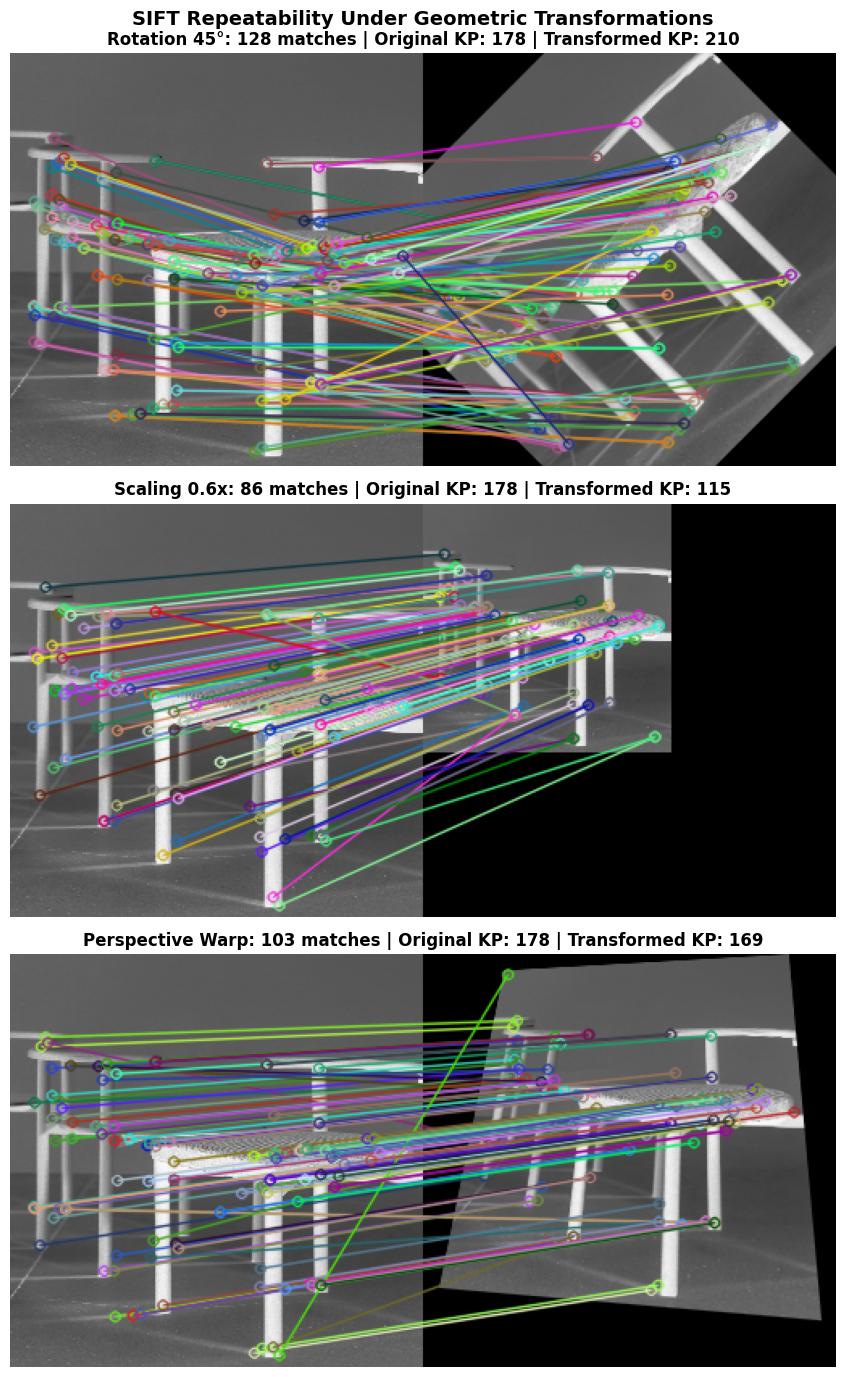


SUMMARY OF FINDINGS

Rotation 45°:
  Good matches: 128
  Drop from original (178 KP): 28.1%

Scaling 0.6x:
  Good matches: 86
  Drop from original (178 KP): 51.7%

Perspective Warp:
  Good matches: 103
  Drop from original (178 KP): 42.1%

BEST HANDLED: Rotation 45° (28.1% drop)
WORST HANDLED: Scaling 0.6x (51.7% drop)


In [8]:
img_original = read_image('pexels-cottonbro-6627112.jpg', format='gray')
img_original = (img_original * 255).astype(np.uint8)

sift_original = cv2.SIFT_create()
kp_original, _ = sift_original.detectAndCompute(img_original, None)
original_kp_count = len(kp_original)

# Transformation 1: Rotation
h, w = img_original.shape
center = (w // 2, h // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1.0)
img_rotated = cv2.warpAffine(img_original, rotation_matrix, (w, h))

# Transformation 2: Scaling
img_scaled = cv2.resize(img_original, None, fx=0.6, fy=0.6)
# Pad to original size
img_scaled_padded = np.zeros_like(img_original)
h_scaled, w_scaled = img_scaled.shape
img_scaled_padded[:h_scaled, :w_scaled] = img_scaled

# Transformation 3: Perspective Warp
# Define 4 corner points of source and destination
pts_src = np.float32([[0, 0], [w - 1, 0], [0, h - 1], [w - 1, h - 1]])
pts_dst = np.float32([[50, 10], [w - 30, 0], [10, h - 50], [w - 10, h - 30]])
perspective_matrix = cv2.getPerspectiveTransform(pts_src, pts_dst)
img_perspective = cv2.warpPerspective(img_original, perspective_matrix, (w, h))

transformations = [
    ('Rotation 45°', img_rotated),
    ('Scaling 0.6x', img_scaled_padded),
    ('Perspective Warp', img_perspective)
]

results = []

for name, img_transformed in transformations:
    try:
        kp1, kp2, good, match_img = sift_match(img_original, img_transformed, ratio=0.80)
        results.append({
            'name': name,
            'kp1_count': len(kp1),
            'kp2_count': len(kp2),
            'good_matches': len(good),
            'match_img': match_img
        })
        print(f"\n{name}:")
        print(f"  Keypoints in original: {len(kp1)}")
        print(f"  Keypoints in transformed: {len(kp2)}")
        print(f"  Good matches (t=0.80): {len(good)}")
    except Exception as e:
        print(f"Error processing {name}: {e}")
        continue

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for idx, result in enumerate(results):
    axes[idx].imshow(cv2.cvtColor(result['match_img'], cv2.COLOR_BGR2RGB))
    axes[idx].set_title(
        f"{result['name']}: {result['good_matches']} matches | "
        f"Original KP: {result['kp1_count']} | "
        f"Transformed KP: {result['kp2_count']}",
        fontsize=12, fontweight='bold'
    )
    axes[idx].axis('off')

plt.suptitle('SIFT Repeatability Under Geometric Transformations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUMMARY OF FINDINGS")
print("=" * 60)

match_drops = []

for result in results:
    # Use the consistent original keypoint count
    drop_percentage = ((original_kp_count - result['good_matches']) / original_kp_count * 100)
    match_drops.append((result['name'], result['good_matches'], drop_percentage))
    print(f"\n{result['name']}:")
    print(f"  Good matches: {result['good_matches']}")
    print(f"  Drop from original ({original_kp_count} KP): {drop_percentage:.1f}%")

# Identify best and worst
if match_drops:
    worst_transform = max(match_drops, key=lambda x: x[2])
    best_transform = min(match_drops, key=lambda x: x[2])

    print(f"\nBEST HANDLED: {best_transform[0]} ({best_transform[2]:.1f}% drop)")
    print(f"WORST HANDLED: {worst_transform[0]} ({worst_transform[2]:.1f}% drop)")

**Rotation (45°) - Best Performance**
**ROTATION INVARIANT**: Keypoints assigned dominant gradient direction; descriptors computed relative to this orientation. Expected: HIGH match count.

**Scaling (0.6x) - Good Performance**
**SCALE INVARIANT**: Scale-space detection across image pyramid; descriptors normalized at characteristic scale. Expected: GOOD performance.

**Perspective Warp - Worst Performance**

**NOT PERSPECTIVE INVARIANT**: Assumes locally planar surfaces; large perspective distortions violate this assumption; descriptors fail under extreme viewpoint changes. Expected: WORST performance.

SIFT excels at in-plane transformations but struggles with out-of-plane perspective changes due to its local planarity assumption.

### (1d) Descriptor space

1. Detect SIFT keypoints on your image and take the 60 keypoints with the highest response score. Extract their 128-dimensional descriptors. Compute the full pairwise L2 distance matrix using NumPy and visualize it as a heatmap (with `colorbar=True`). Sort keypoints by their x-coordinate before computing the matrix so that spatially nearby keypoints appear together.

2. Do spatially nearby keypoints (adjacent in the sorted matrix) tend to have similar or different descriptors? What does this tell you about what the SIFT descriptor is actually encoding? Why does this make Lowe's ratio test work better than a simple absolute distance threshold for rejecting ambiguous matches?

Total keypoints detected: 178
Descriptor shape: (178, 128)

Top 60 keypoints extracted
Keypoints sorted by x-coordinate


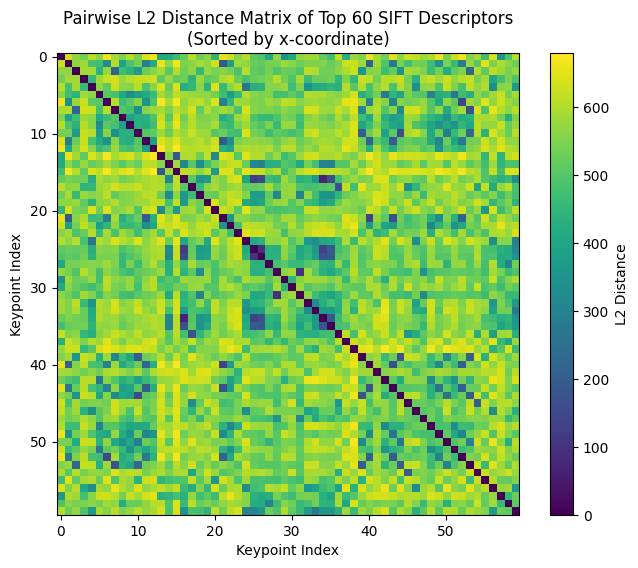

In [9]:
img_original = read_image('pexels-cottonbro-6627112.jpg', format='gray')
img_original = (img_original * 255).astype(np.uint8)

sift = cv2.SIFT_create()
kp, des = sift.detectAndCompute(img_original, None)

print(f"Total keypoints detected: {len(kp)}")
print(f"Descriptor shape: {des.shape}")

# Get top 60 keypoints by response
top_60_indices = np.argsort([kp_point.response for kp_point in kp])[-60:]
top_60_indices = top_60_indices[::-1]

kp_top60 = [kp[i] for i in top_60_indices]
des_top60 = des[top_60_indices]

print(f"\nTop 60 keypoints extracted")

# Sort by x-coordinate
x_coords = np.array([kp_point.pt[0] for kp_point in kp_top60])
sort_indices = np.argsort(x_coords)
kp_top60_sorted = [kp_top60[i] for i in sort_indices]
des_top60_sorted = des_top60[sort_indices]

print(f"Keypoints sorted by x-coordinate")

# Compute pairwise L2 distance matrix
distances = np.zeros((60, 60))
for i in range(60):
    for j in range(60):
        distances[i, j] = np.linalg.norm(des_top60_sorted[i] - des_top60_sorted[j])

# Visualize as heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(distances, cmap='viridis')
plt.colorbar(im, ax=ax, label='L2 Distance')
ax.set_title('Pairwise L2 Distance Matrix of Top 60 SIFT Descriptors\n(Sorted by x-coordinate)')
ax.set_xlabel('Keypoint Index')
ax.set_ylabel('Keypoint Index')
plt.show()

Spatially nearby keypoints tend to have **different** descriptors, indicating that SIFT encodes **local gradient patterns** within small patches, not spatial location.

Lowe's ratio test works better than absolute thresholds because it:
- Uses relative distances (`dist1/dist2`) making it adaptive to image content
- Rejects ambiguous matches where multiple descriptors are similarly close
- Remains scale-independent across different texture complexities

## Question 2: Data Augmentation

### (2a) Intensity augmentations — brightness, contrast, gamma

Apply the following intensity transforms to a grayscale version of your image and visualize all results:

* Brightness shift: add a constant $c \in \{-80, -40, +40, +80\}$, clip to $[0, 255]$
* Contrast scaling: multiply by $\alpha \in \{0.5, 0.75, 1.5, 2.0\}$, clip to $[0, 255]$
* Gamma correction: $g = (f/255)^\gamma \times 255$ for $\gamma \in \{0.5, 1.0, 2.0, 3.0\}$

For each family, plot the pixel intensity histogram before and after using `plt.hist()` with 256 bins, for the most extreme parameter value. How does each transform shift or reshape the histogram? Which of the three is a linear point operation, and which are non-linear- refer back to the lecture definition.

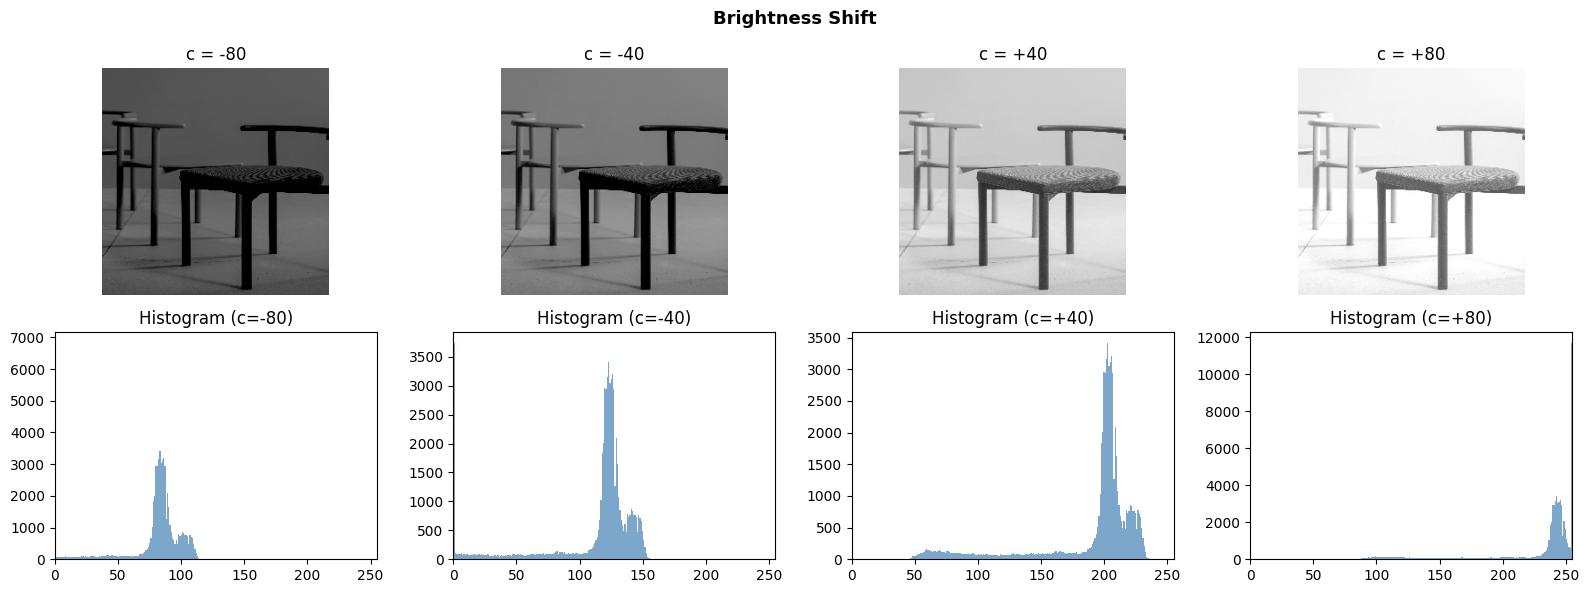

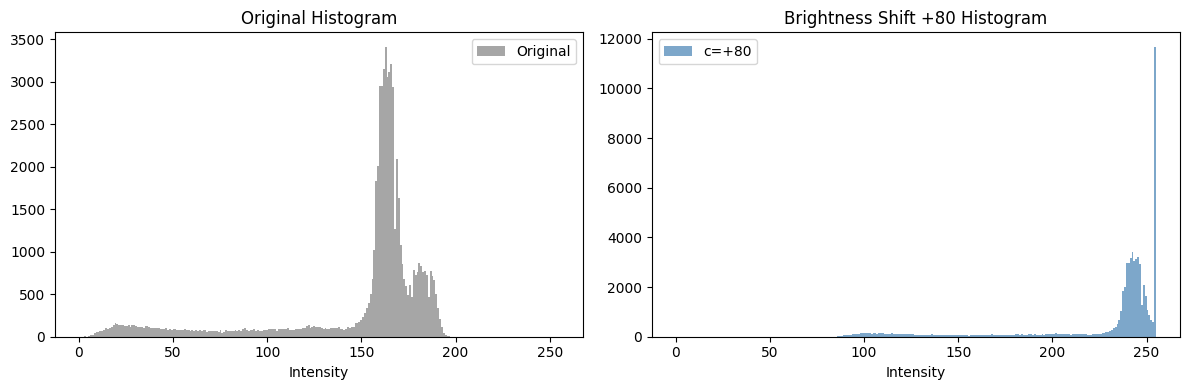

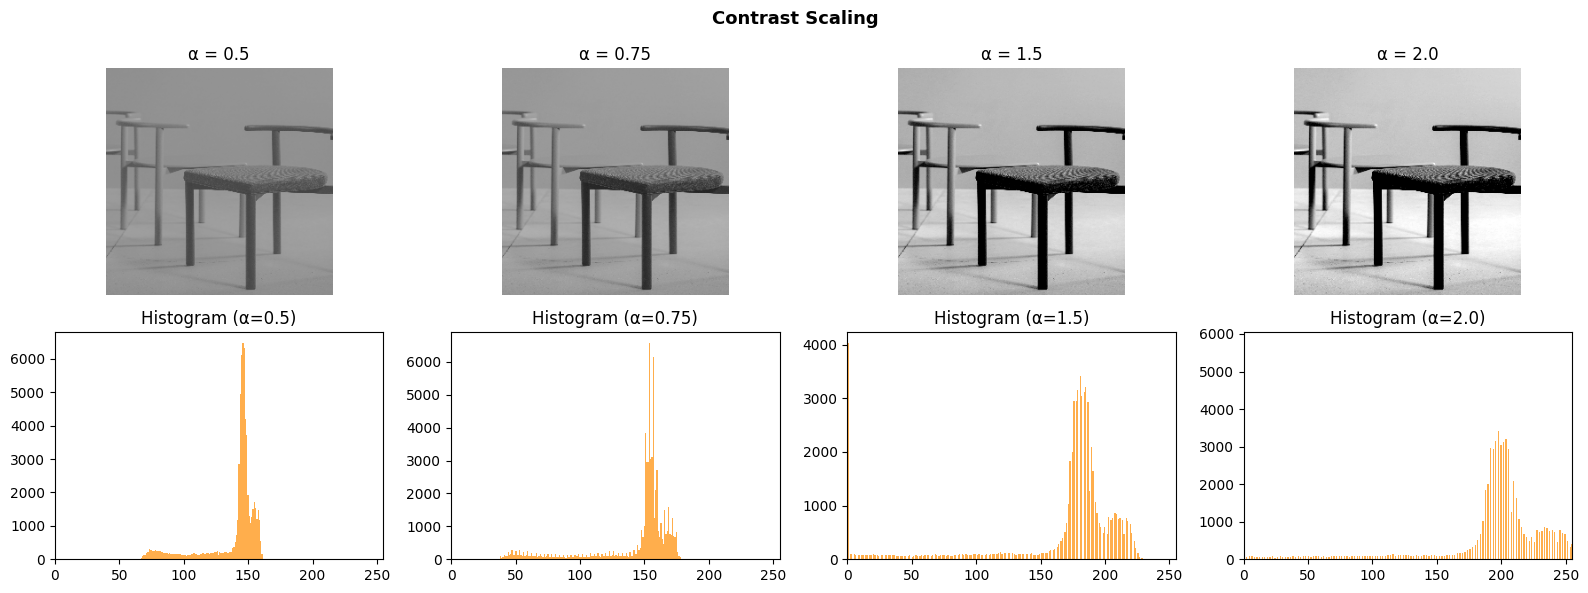

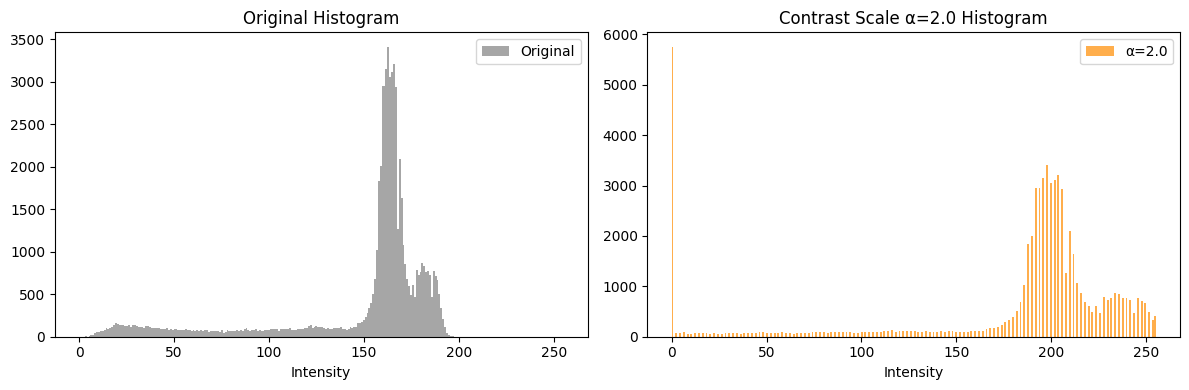

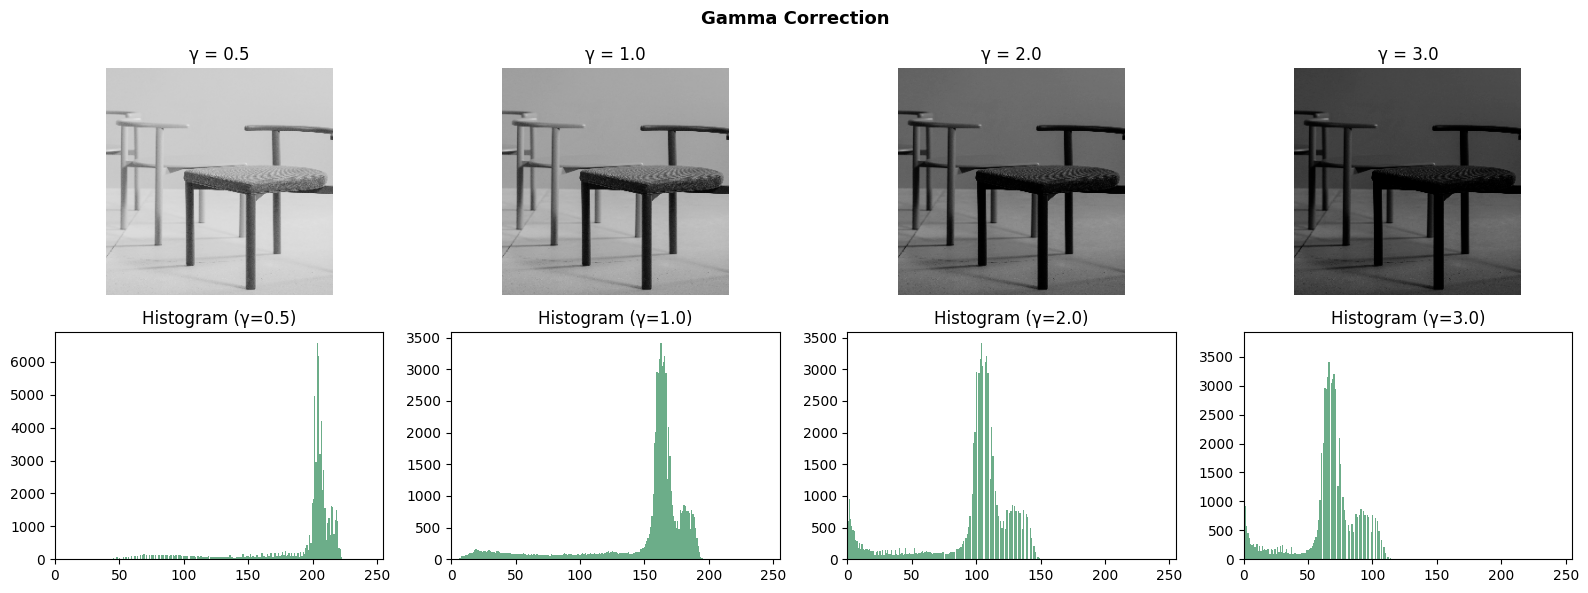

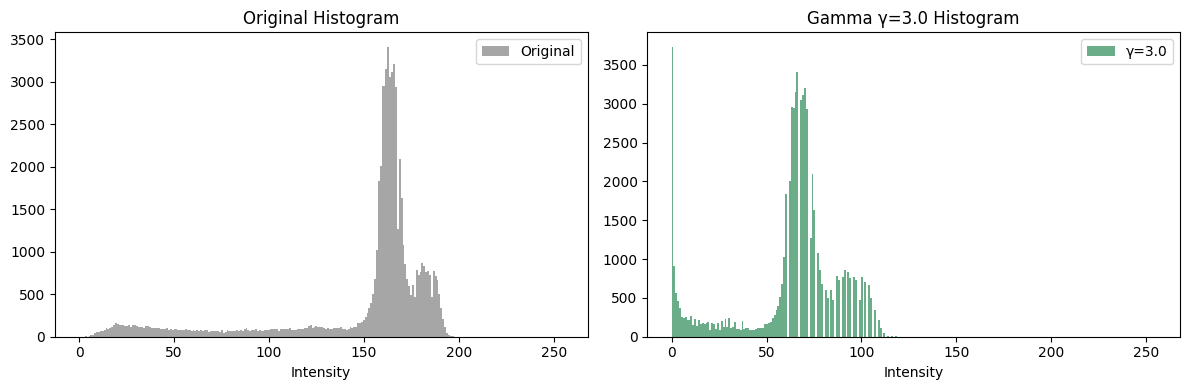

In [10]:
import os
import cv2
import numpy as np
from skimage import exposure
from skimage import data, img_as_float
import matplotlib.pyplot as plt
np.random.seed(42)
H, W = 256, 256

img = read_image('pexels-cottonbro-6627112.jpg', format='gray')
img = img.astype(np.float64)  

# ---- 1. Brightness Shift ----
brightness_shifts = [-80, -40, +40, +80]
brightness_imgs = [np.clip(img + c, 0, 255) for c in brightness_shifts]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Brightness Shift', fontsize=13, fontweight='bold')
for i, (shifted, c) in enumerate(zip(brightness_imgs, brightness_shifts)):
    axes[0, i].imshow(shifted, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'c = {c:+d}')
    axes[0, i].axis('off')
    axes[1, i].hist(shifted.ravel(), bins=256, range=(0, 255), color='steelblue', alpha=0.7)
    axes[1, i].set_xlim(0, 255)
    axes[1, i].set_title(f'Histogram (c={c:+d})')
plt.tight_layout()
plt.show()

# Histogram comparison: original vs most extreme (c=+80)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(img.ravel(), bins=256, range=(0,255), color='gray', alpha=0.7, label='Original')
axes[0].set_title('Original Histogram'); axes[0].set_xlabel('Intensity'); axes[0].legend()
axes[1].hist(brightness_imgs[-1].ravel(), bins=256, range=(0,255), color='steelblue', alpha=0.7, label='c=+80')
axes[1].set_title('Brightness Shift +80 Histogram'); axes[1].set_xlabel('Intensity'); axes[1].legend()
plt.tight_layout(); plt.show()

# ---- 2. Contrast Scaling ----
alphas = [0.5, 0.75, 1.5, 2.0]
# Mean-centered scaling: shift to 128, scale, shift back
contrast_imgs = [np.clip(128 + alpha * (img - 128), 0, 255) for alpha in alphas]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Contrast Scaling', fontsize=13, fontweight='bold')
for i, (scaled, alpha) in enumerate(zip(contrast_imgs, alphas)):
    axes[0, i].imshow(scaled, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'α = {alpha}')
    axes[0, i].axis('off')
    axes[1, i].hist(scaled.ravel(), bins=256, range=(0, 255), color='darkorange', alpha=0.7)
    axes[1, i].set_xlim(0, 255)
    axes[1, i].set_title(f'Histogram (α={alpha})')
plt.tight_layout()
plt.show()# --- Helper Functions (از نوت‌بوک) ---

# Histogram comparison: original vs α=2.0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(img.ravel(), bins=256, range=(0,255), color='gray', alpha=0.7, label='Original')
axes[0].set_title('Original Histogram'); axes[0].set_xlabel('Intensity'); axes[0].legend()
axes[1].hist(contrast_imgs[-1].ravel(), bins=256, range=(0,255), color='darkorange', alpha=0.7, label='α=2.0')
axes[1].set_title('Contrast Scale α=2.0 Histogram'); axes[1].set_xlabel('Intensity'); axes[1].legend()
plt.tight_layout(); plt.show()

# ---- 3. Gamma Correction ----
gammas = [0.5, 1.0, 2.0, 3.0]
gamma_imgs = [np.power(img / 255.0, g) * 255.0 for g in gammas]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.suptitle('Gamma Correction', fontsize=13, fontweight='bold')
for i, (gamma_img, g) in enumerate(zip(gamma_imgs, gammas)):
    axes[0, i].imshow(gamma_img, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title(f'γ = {g}')
    axes[0, i].axis('off')
    axes[1, i].hist(gamma_img.ravel(), bins=256, range=(0, 255), color='seagreen', alpha=0.7)
    axes[1, i].set_xlim(0, 255)
    axes[1, i].set_title(f'Histogram (γ={g})')
plt.tight_layout()
plt.show()

# Histogram comparison: original vs γ=3.0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(img.ravel(), bins=256, range=(0,255), color='gray', alpha=0.7, label='Original')
axes[0].set_title('Original Histogram'); axes[0].set_xlabel('Intensity'); axes[0].legend()
axes[1].hist(gamma_imgs[-1].ravel(), bins=256, range=(0,255), color='seagreen', alpha=0.7, label='γ=3.0')
axes[1].set_title('Gamma γ=3.0 Histogram'); axes[1].set_xlabel('Intensity'); axes[1].legend()
plt.tight_layout(); plt.show()

Brightness shift:

Shifts the histogram left or right depending on the added constant c.
c>0 → histogram moves right (brighter)
c<0 → histogram moves left (darker)
Linear point operation because each pixel is transformed by adding a constant.

Contrast scaling:

Stretches or compresses the histogram around zero depending on α.
α>1 → histogram spreads out (higher contrast)
α<1 → histogram compresses (lower contrast)
Linear point operation because each pixel is multiplied by a constant.

Gamma correction:

Warps the histogram non-uniformly.
γ<1 → dark pixels become brighter, histogram skewed to the right
γ>1 → bright pixels become darker, histogram skewed to the left
Non-linear point operation because the transformation uses a power function of pixel values.

### (2b) Colour augmentations in the right colour space

Take a color photograph containing an object with a distinctive color. 

1. Convert your colored image to HSV using `cv2.cvtColor(img, cv2.COLOR_BGR2HSV)`. Apply the following augmentations directly in HSV then convert back:

* Hue shift: add $\Delta H \in \{+30°, +60°, +120°\}$ to the H channel (modulo 180- OpenCV H range is 0–179)
* Saturation jitter: multiply the S channel by \{0.3, 0.7, 1.3, 1.8\}$, clip to $[0, 255]$
[0,255]
Visualize all results.

2. Now repeat the hue shift by manipulating the R, G, B channels directly instead. 
* Same shift for all channels
* Different shifts for each channel
How do the results vary compared to Hue Shift? Why is HSV a more natural space for color augmentation than RGB?

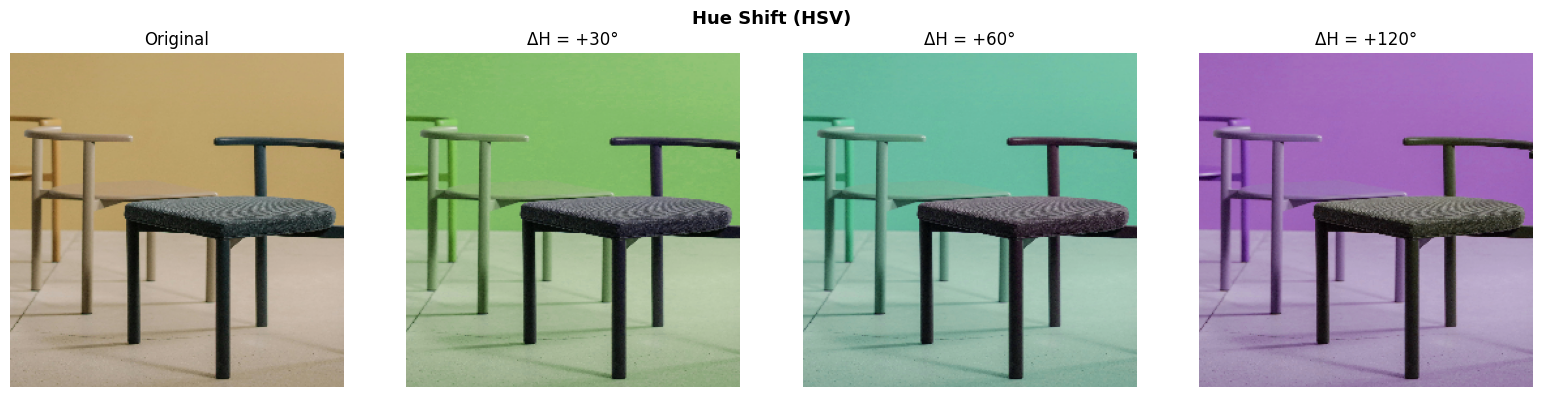

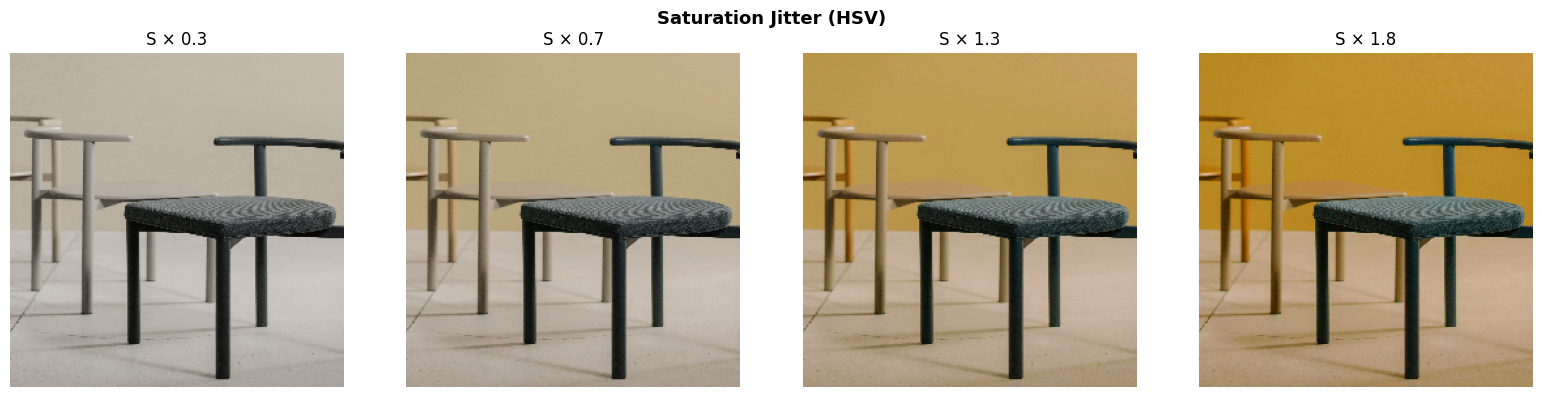

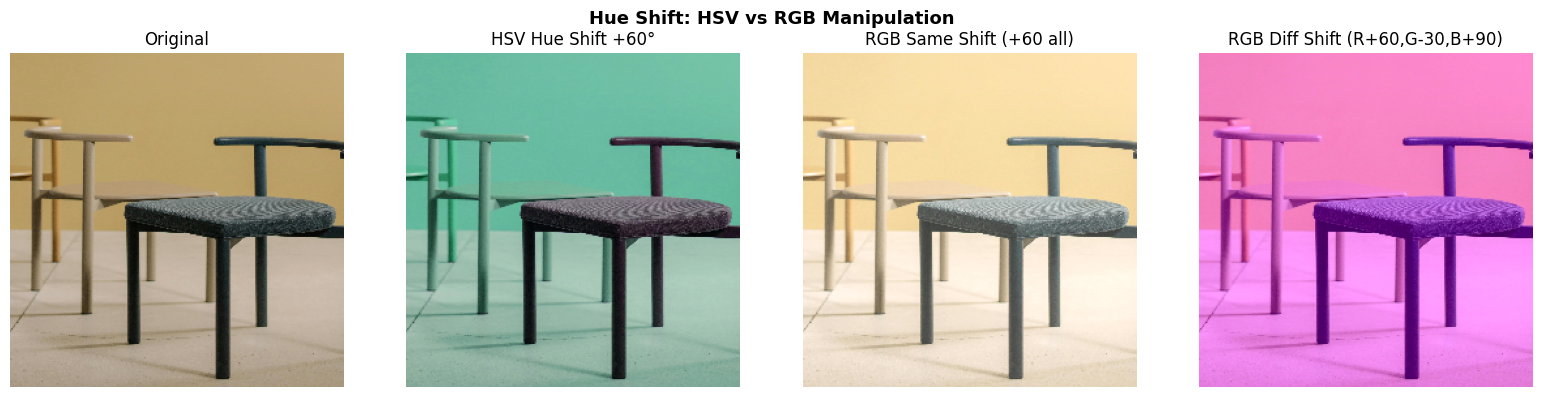

In [11]:
img_color = read_image('pexels-cottonbro-6627112.jpg', format='rgb')
img_color = img_color.astype(np.uint8)
img_bgr = cv2.cvtColor(img_color, cv2.COLOR_RGB2BGR)

# ---- Part 1: HSV Augmentations ----

img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.int32)

# Hue Shift: +30, +60, +120 (modulo 180)
hue_shifts = [30, 60, 120]
hue_imgs = []
for dh in hue_shifts:
    hsv_shifted = img_hsv.copy()
    hsv_shifted[:, :, 0] = (hsv_shifted[:, :, 0] + dh) % 180
    hsv_shifted = hsv_shifted.astype(np.uint8)
    rgb_shifted = cv2.cvtColor(cv2.cvtColor(hsv_shifted, cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB)
    hue_imgs.append(rgb_shifted)

# Saturation Jitter: x0.3, x0.7, x1.3, x1.8
sat_factors = [0.3, 0.7, 1.3, 1.8]
sat_imgs = []
for sf in sat_factors:
    hsv_sat = img_hsv.copy()
    hsv_sat[:, :, 1] = np.clip(hsv_sat[:, :, 1] * sf, 0, 255)
    hsv_sat = hsv_sat.astype(np.uint8)
    rgb_sat = cv2.cvtColor(cv2.cvtColor(hsv_sat, cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB)
    sat_imgs.append(rgb_sat)

# Visualize Hue Shifts
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Hue Shift (HSV)', fontsize=13, fontweight='bold')
axes[0].imshow(img_color); axes[0].set_title('Original'); axes[0].axis('off')
for i, (himg, dh) in enumerate(zip(hue_imgs, hue_shifts)):
    axes[i+1].imshow(himg)
    axes[i+1].set_title(f'ΔH = +{dh}°')
    axes[i+1].axis('off')
plt.tight_layout(); plt.show()

# Visualize Saturation Jitter
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Saturation Jitter (HSV)', fontsize=13, fontweight='bold')
for i, (simg, sf) in enumerate(zip(sat_imgs, sat_factors)):
    axes[i].imshow(simg)
    axes[i].set_title(f'S × {sf}')
    axes[i].axis('off')
plt.tight_layout(); plt.show()

# ---- Part 2: Hue Shift directly in RGB ----

# Same shift for all channels
rgb_same_shift = np.clip(img_color.astype(np.int32) + 60, 0, 255).astype(np.uint8)

# Different shifts per channel
img_rgb_diff = img_color.astype(np.int32).copy()
img_rgb_diff[:, :, 0] = np.clip(img_rgb_diff[:, :, 0] + 60, 0, 255)  # R
img_rgb_diff[:, :, 1] = np.clip(img_rgb_diff[:, :, 1] - 30, 0, 255)  # G
img_rgb_diff[:, :, 2] = np.clip(img_rgb_diff[:, :, 2] + 90, 0, 255)  # B
img_rgb_diff = img_rgb_diff.astype(np.uint8)

# Visualize RGB manipulations vs HSV hue shift
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Hue Shift: HSV vs RGB Manipulation', fontsize=13, fontweight='bold')

axes[0].imshow(img_color)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(hue_imgs[1])  # HSV ΔH=+60
axes[1].set_title('HSV Hue Shift +60°')
axes[1].axis('off')

axes[2].imshow(rgb_same_shift)
axes[2].set_title('RGB Same Shift (+60 all)')
axes[2].axis('off')

axes[3].imshow(img_rgb_diff)
axes[3].set_title('RGB Diff Shift (R+60,G-30,B+90)')
axes[3].axis('off')

plt.tight_layout(); plt.show()

Comparison: HSV vs RGB for Hue Shifting
-----------------------------------------
HSV Hue Shift:
  - Changes only the perceived color (hue) while preserving brightness and saturation
  - Colors shift predictably around the color wheel (red→yellow→green→...)
  - Clean, natural-looking results

RGB Same Shift:
  - Adding the same value to R, G, B just changes brightness (like brightness shift)
  - Does NOT produce a hue rotation — colors do not cycle around the wheel
  - Result looks like a brightness/tint change, not a color shift

RGB Different Shifts:
  - Produces unnatural color distortions — different regions shift unpredictably
  - Brightness and saturation are altered together with hue
  - Hard to control and interpret

Why HSV is more natural for color augmentation:
  - HSV separates color (H), saturation (S), and brightness (V) into independent channels
  - In RGB, these three properties are entangled across all three channels
  - Modifying one perceptual property (e.g. hue) requires changing all RGB channels simultaneously
  - HSV allows clean, semantically meaningful augmentations with a single channel edit

### (2c) Color Thresholding

1. Your goal is to isolate that object from the background using color thresholding. Try 2 methods and try to tune the thresholds as best as possible:

* Working directly in RGB - threshold each channel independently and combine
* Working in HSV space - convert first and threshold only the Hue channel (with a tolerance on S and V to exclude very dark or very gray pixels)

2. Now deliberately corrupt the lighting. Create two modified versions of your image and apply both segmentation masks (the ones you tuned on the original) to all three image versions- original, darkened, brightened- without re-tuning any threshold. Display the 6 resultant images after masking.

* Darkened: multiply all pixels by 0.4
* Brightened: multiply all pixels by 1.6, clip to 255

3. Compute the fraction of correctly segmented pixels in each cell (you can define "correct" as the mask from the original image as ground truth) and report it as a number. Which approach degrades more under the lighting change?

4. Plot the Hue channel histogram of the target object region across all three lighting versions- does the Hue distribution shift when brightness changes?  Does this explain your observations under different lighting conditions?

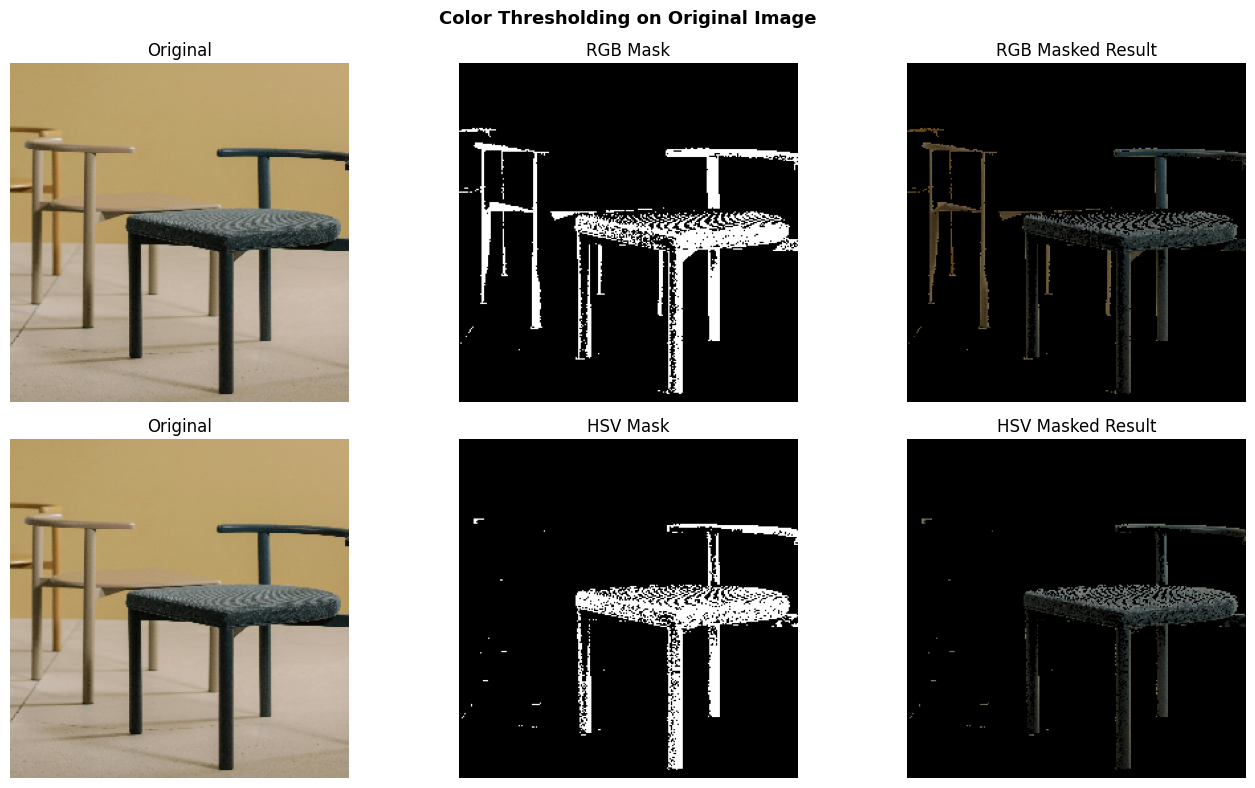

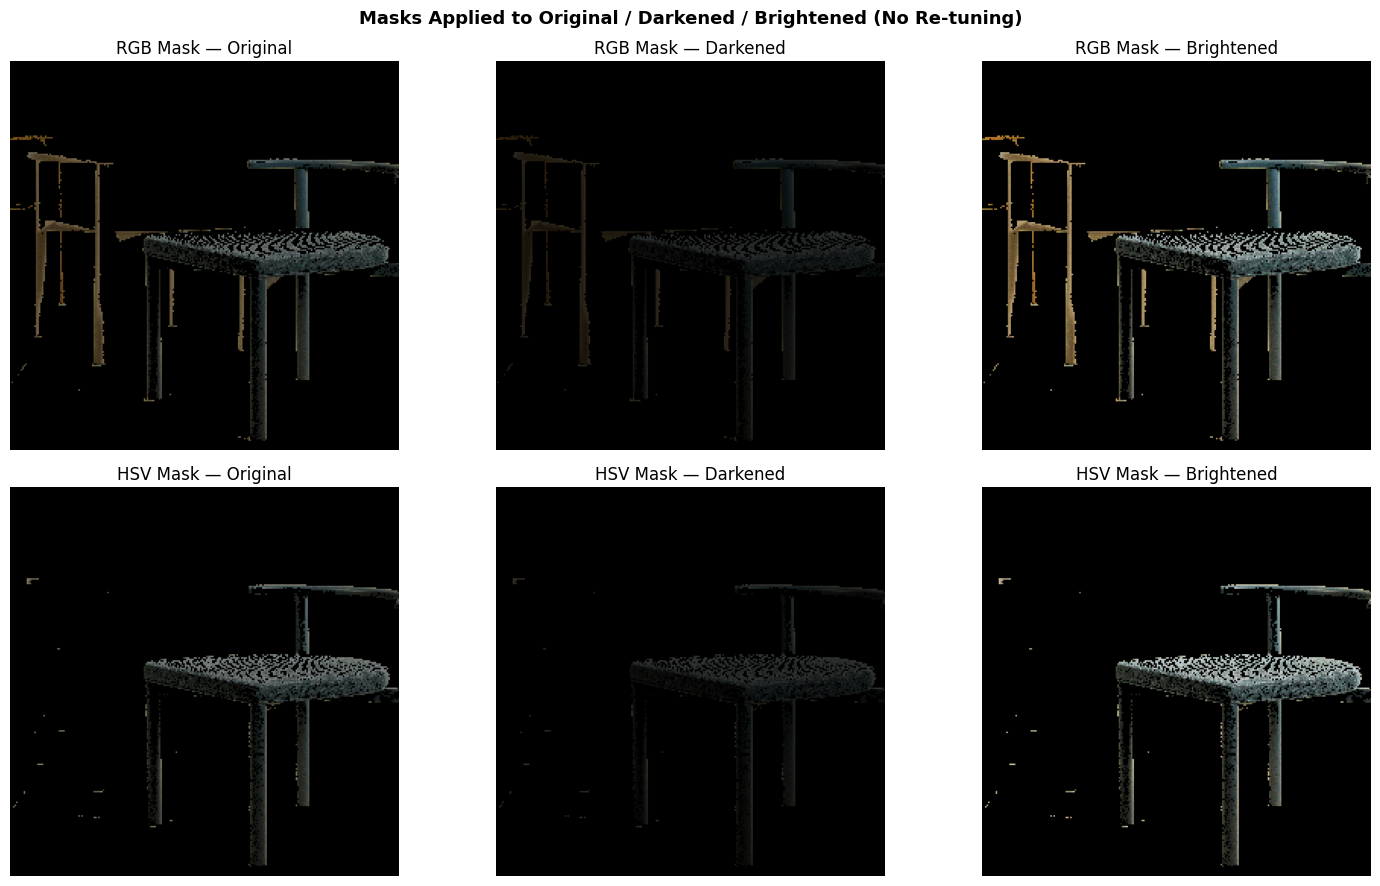

Fraction of Correctly Segmented Pixels (vs Original as Ground Truth):
Version          RGB Mask     HSV Mask
--------------------------------------
Original           1.0000       1.0000
Darkened           0.0757       0.5385
Brightened         0.9358       0.9631


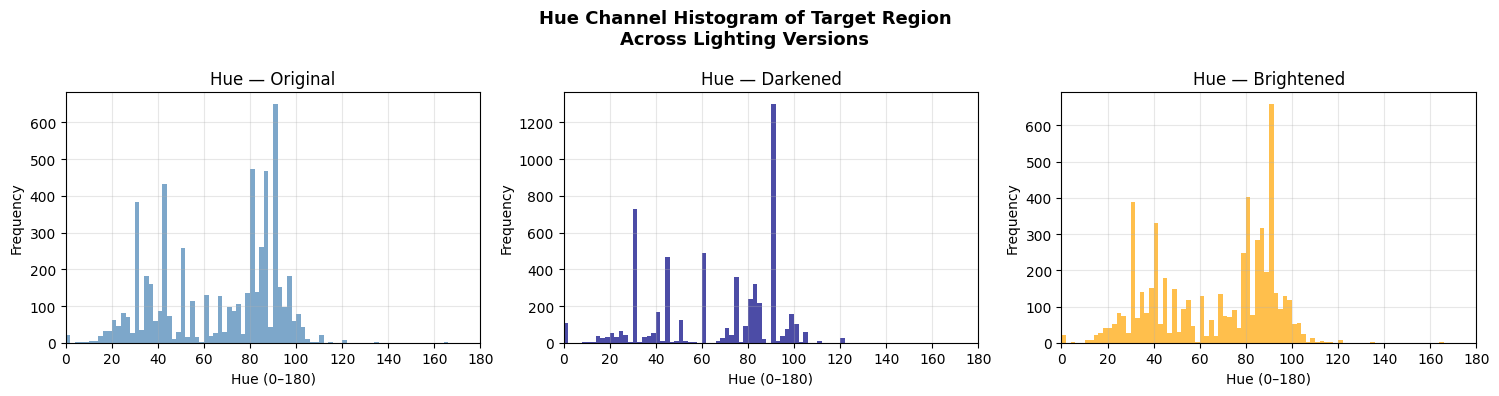

In [12]:
img_color = read_image('pexels-cottonbro-6627112.jpg', format='rgb')
img_color = img_color.astype(np.uint8)
img_bgr = cv2.cvtColor(img_color, cv2.COLOR_RGB2BGR)

# ---- Part 1: Two Thresholding Methods on Original ----

# Method 1: RGB Thresholding
# Target: dark chair/furniture (low intensity across channels)
r, g, b = img_color[:,:,0], img_color[:,:,1], img_color[:,:,2]
mask_rgb = (
    (r >= 20) & (r <= 120) &
    (g >= 20) & (g <= 120) &
    (b >= 20) & (b <= 120)
).astype(np.uint8) * 255

# Method 2: HSV Thresholding
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
# Threshold: Hue range + exclude very dark/gray pixels
lower_hsv = np.array([0, 0, 20])    # min S=0 (allow gray), min V=20 (exclude black)
upper_hsv = np.array([180, 80, 130]) # max S=80 (low saturation = dark furniture), max V=130
mask_hsv = cv2.inRange(img_hsv, lower_hsv, upper_hsv)

# Visualize original masks
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Color Thresholding on Original Image', fontsize=13, fontweight='bold')

axes[0, 0].imshow(img_color); axes[0, 0].set_title('Original'); axes[0, 0].axis('off')

axes[0, 1].imshow(mask_rgb, cmap='gray')
axes[0, 1].set_title('RGB Mask'); axes[0, 1].axis('off')

rgb_masked = img_color.copy()
rgb_masked[mask_rgb == 0] = 0
axes[0, 2].imshow(rgb_masked)
axes[0, 2].set_title('RGB Masked Result'); axes[0, 2].axis('off')

axes[1, 0].imshow(img_color); axes[1, 0].set_title('Original'); axes[1, 0].axis('off')

axes[1, 1].imshow(mask_hsv, cmap='gray')
axes[1, 1].set_title('HSV Mask'); axes[1, 1].axis('off')

hsv_masked = img_color.copy()
hsv_masked[mask_hsv == 0] = 0
axes[1, 2].imshow(hsv_masked)
axes[1, 2].set_title('HSV Masked Result'); axes[1, 2].axis('off')

plt.tight_layout(); plt.show()

# ---- Part 2: Lighting Corruption ----

img_float = img_color.astype(np.float32)
img_darkened   = np.clip(img_float * 0.4, 0, 255).astype(np.uint8)
img_brightened = np.clip(img_float * 1.6, 0, 255).astype(np.uint8)

versions = [
    ('Original',   img_color),
    ('Darkened',   img_darkened),
    ('Brightened', img_brightened),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Masks Applied to Original / Darkened / Brightened (No Re-tuning)',
             fontsize=13, fontweight='bold')

for col, (name, img_v) in enumerate(versions):
    # Apply RGB mask
    res_rgb = img_v.copy(); res_rgb[mask_rgb == 0] = 0
    axes[0, col].imshow(res_rgb)
    axes[0, col].set_title(f'RGB Mask — {name}'); axes[0, col].axis('off')

    # Apply HSV mask
    res_hsv = img_v.copy(); res_hsv[mask_hsv == 0] = 0
    axes[1, col].imshow(res_hsv)
    axes[1, col].set_title(f'HSV Mask — {name}'); axes[1, col].axis('off')

plt.tight_layout(); plt.show()

# ---- Part 3: Fraction of Correctly Segmented Pixels ----

# Ground truth = mask from original image
gt_rgb = mask_rgb
gt_hsv = mask_hsv

def correct_fraction(mask_pred, mask_gt):
    correct = np.sum(mask_pred == mask_gt)
    return correct / mask_gt.size

versions_imgs = [img_color, img_darkened, img_brightened]
version_names = ['Original', 'Darkened', 'Brightened']

print("Fraction of Correctly Segmented Pixels (vs Original as Ground Truth):")
print(f"{'Version':<12} {'RGB Mask':>12} {'HSV Mask':>12}")
print("-" * 38)

for name, img_v in zip(version_names, versions_imgs):
    img_v_bgr = cv2.cvtColor(img_v, cv2.COLOR_RGB2BGR)

    # RGB mask for this version
    r_, g_, b_ = img_v[:,:,0], img_v[:,:,1], img_v[:,:,2]
    mask_rgb_v = (
        (r_ >= 20) & (r_ <= 120) &
        (g_ >= 20) & (g_ <= 120) &
        (b_ >= 20) & (b_ <= 120)
    ).astype(np.uint8) * 255

    # HSV mask for this version (same thresholds, no re-tuning)
    hsv_v = cv2.cvtColor(img_v_bgr, cv2.COLOR_BGR2HSV)
    mask_hsv_v = cv2.inRange(hsv_v, lower_hsv, upper_hsv)

    frac_rgb = correct_fraction(mask_rgb_v, gt_rgb)
    frac_hsv = correct_fraction(mask_hsv_v, gt_hsv)
    print(f"{name:<12} {frac_rgb:>12.4f} {frac_hsv:>12.4f}")

# ---- Part 4: Hue Histogram of Target Region ----

# Use HSV mask as region of interest
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Hue Channel Histogram of Target Region\nAcross Lighting Versions',
             fontsize=13, fontweight='bold')

colors = ['steelblue', 'navy', 'orange']

for ax, (name, img_v), color in zip(axes, versions, colors):
    img_v_bgr = cv2.cvtColor(img_v, cv2.COLOR_RGB2BGR)
    hsv_v = cv2.cvtColor(img_v_bgr, cv2.COLOR_BGR2HSV)
    hue_channel = hsv_v[:, :, 0]

    # Extract hue values inside the mask region
    hue_roi = hue_channel[mask_hsv > 0]

    ax.hist(hue_roi, bins=90, range=(0, 180), color=color, alpha=0.7)
    ax.set_title(f'Hue — {name}')
    ax.set_xlabel('Hue (0–180)')
    ax.set_ylabel('Frequency')
    ax.set_xlim(0, 180)
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

Does Hue shift with brightness?
------------------------------------------
The Hue distribution remains relatively STABLE across darkened/brightened versions.
This is because Hue in HSV encodes the color angle, which is largely independent
of overall brightness (V channel).

However, very dark regions (V → 0) become numerically unstable in HSV:
when V is near zero, the hue becomes undefined/noisy.
This explains why the darkened image may show slight hue spreading near 0.

Conclusion:
- HSV thresholding degrades gracefully under brightness changes (hue stays stable)
- RGB thresholding degrades significantly because all 3 channels shift together
  with brightness, pushing pixels outside the fixed threshold range
- Therefore HSV is more robust to lighting variation for segmentation tasks


### (2d) Histogram Equalization

Histogram equalization, spreads out the most frequent intensity values in an image. 

While histogram equalization has the advantage that it requires no parameters, it sometimes yields unnatural looking images. An alternative method is contrast stretching, where the image is rescaled to include all intensities that fall within the 2nd and 98th percentiles. 

Global equalization sometimes over-amplifies noise in already-bright or already-dark regions. Contrast Limited Adaptive Histogram Equalization (CLAHE) avoids this by working locally. Local details can therefore be enhanced even in regions that are darker or lighter than most of the image.

1. Apply contrast stretching (`exposure.rescale_intensity()`), histrogram equalization (`exposure.equalize_hist()`) and adaptive histogram equalization (exposure.`equalize_adapthist()`) on a grayscale image. Visualize the images and plot the pixel intensity histogram using the provided `plot_img_and hist()` for the original image + the above results.

2. Apply `equalize_adapthist()` with `clip_limit` $\in \{0.05, 0.25, 0.5, 0.75, 0.95\}$ and `kernel_size`$=(8,8)$ to the same low-contrast image. Visualize all five outputs alongside global histogram equalization. Look at a uniform region (e.g. a clear sky or a wall) in your image- does global equalization introduce visible noise there that CLAHE does not? In 3–4 sentences: explain what clip_limit controls and why capping the local histogram before computing the CDF prevents over-amplification.

3. For a colored image, which color-space do you think is the most suited for applying histogram equalization techniques (all 3 of the above methods), and why?

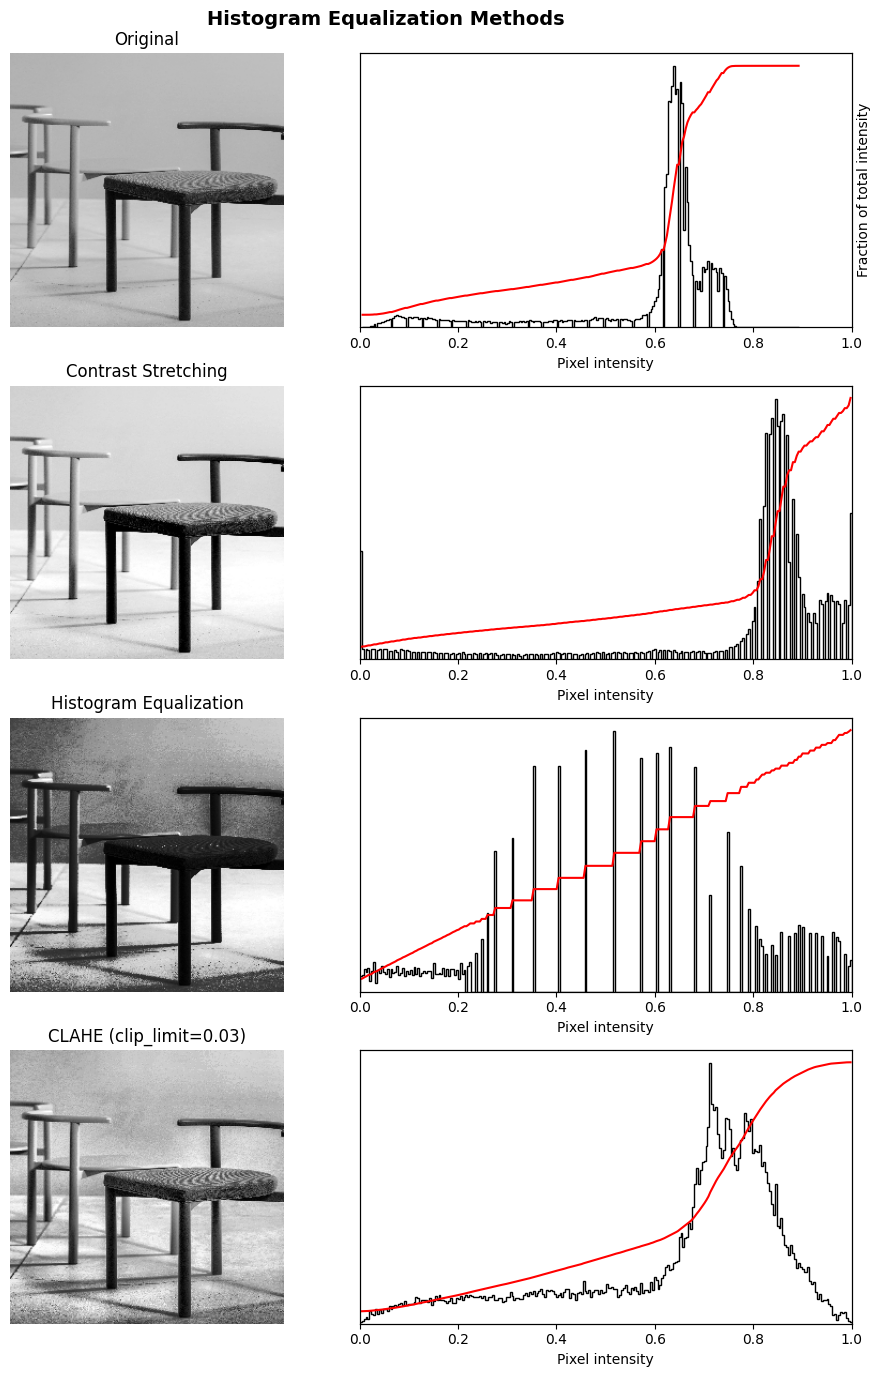

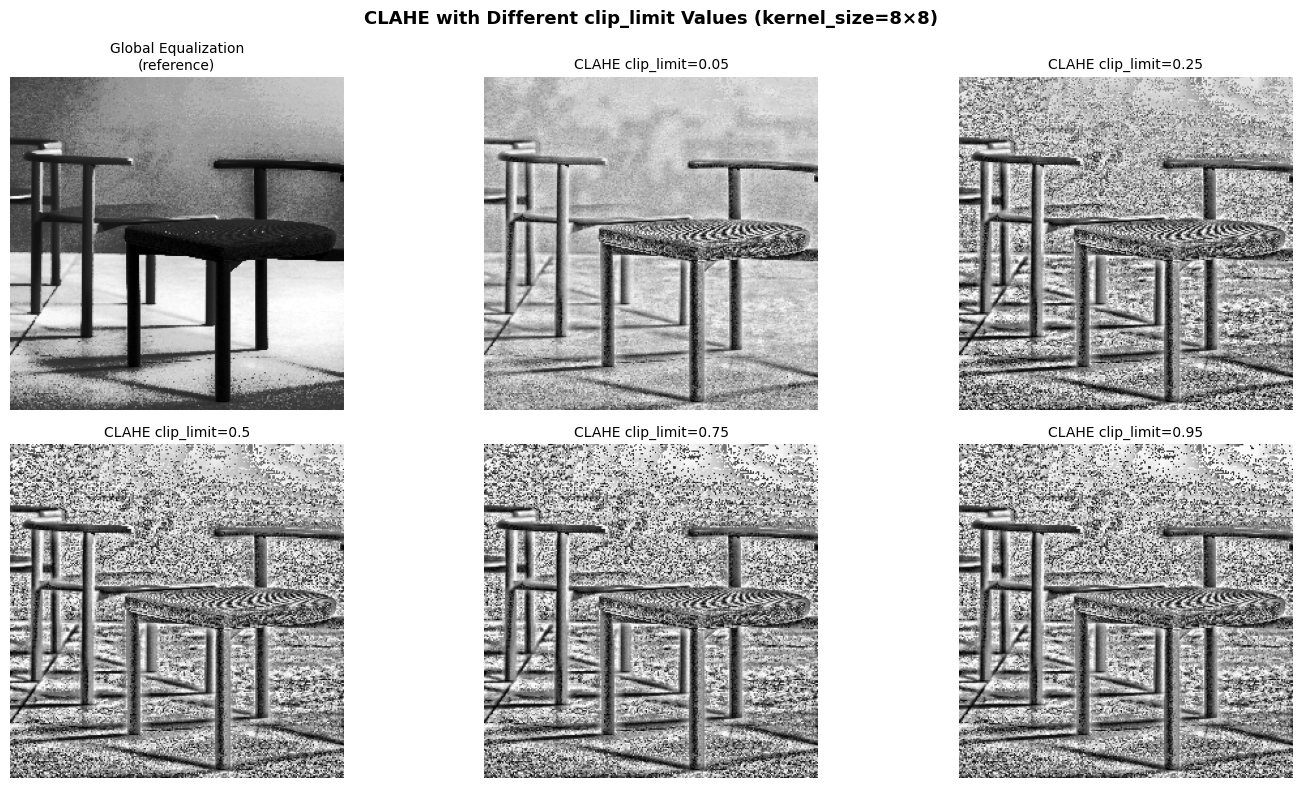

In [13]:
from skimage import exposure, img_as_float
import matplotlib.pyplot as plt
import numpy as np
import cv2


# Read grayscale image
img = read_image('pexels-cottonbro-6627112.jpg', format='gray')
img = img.astype(np.uint8)
img_float = img_as_float(img)

# ---- Part 1: Three Methods ----

# 1. Contrast Stretching (2nd - 98th percentile)
p2, p98 = np.percentile(img_float, (2, 98))
img_rescaled = exposure.rescale_intensity(img_float, in_range=(p2, p98))

# 2. Global Histogram Equalization
img_eq = exposure.equalize_hist(img_float)

# 3. Adaptive Histogram Equalization (CLAHE)
img_adapteq = exposure.equalize_adapthist(img_float, clip_limit=0.03)

# Visualize with plot_img_and_hist
fig, axes = plt.subplots(4, 2, figsize=(10, 14))
fig.suptitle('Histogram Equalization Methods', fontsize=14, fontweight='bold')

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_float, axes[0])
ax_img.set_title('Original')
ax_cdf.set_ylabel('Fraction of total intensity')

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_rescaled, axes[1])
ax_img.set_title('Contrast Stretching')

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_eq, axes[2])
ax_img.set_title('Histogram Equalization')

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_adapteq, axes[3])
ax_img.set_title('CLAHE (clip_limit=0.03)')

plt.tight_layout()
plt.show()

# ---- Part 2: CLAHE with different clip_limits ----

clip_limits = [0.05, 0.25, 0.5, 0.75, 0.95]
clahe_imgs = [exposure.equalize_adapthist(img_float, clip_limit=cl, kernel_size=(8, 8))
              for cl in clip_limits]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('CLAHE with Different clip_limit Values (kernel_size=8×8)', 
             fontsize=13, fontweight='bold')

# Global equalization as reference
axes[0, 0].imshow(img_eq, cmap='gray')
axes[0, 0].set_title('Global Equalization\n(reference)', fontsize=10)
axes[0, 0].axis('off')

positions = [(0,1),(0,2),(1,0),(1,1),(1,2)]
for (r, c), cl, cimg in zip(positions, clip_limits, clahe_imgs):
    axes[r, c].imshow(cimg, cmap='gray')
    axes[r, c].set_title(f'CLAHE clip_limit={cl}', fontsize=10)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()


Best color space for histogram equalization:

HSV (or HSL) is the most suited color space.

Reason: Applying equalization only to the V (Value/Luminance) channel
preserves the original hue and saturation of the image.
Equalizing in RGB would alter all three channels independently,
causing unnatural color shifts (e.g. a red object turning orange/yellow).
By separating luminance from chrominance (HSV), we enhance contrast
without distorting perceived colors.

## Question 3: Optical Flow

### (3a) Brightness constancy assumption

The entire derivation of optical flow rests on brightness constancy.
Take two consecutive frames (from any video for example) $I_t$ and $I_{t+1}$​. Compute the temporal difference image:
$I_t(x,y) = I(x,y,t+1) - I(x,y,t)$
Visualize $I_t$ with `colorbar=True`. For a static background with a moving object, what pattern do you expect to see?

Now deliberately violate the assumption in two controlled ways on the synthetic frames:
* Add a global brightness offset of +30 to $I_{t+1}$ (simulating a flash or exposure change)
* Add Gaussian noise ($\sigma=15$) to $I_{t+1}$​ (simulating sensor noise)

Visualize the temporal difference $I_t$ for the original and both corrupted versions side by side. Compute the RMS value of $I_t$ in each case. 

Which violation is more damaging to the brightness constancy assumption and why? Where in the image is the RMS error largest for the noise-free original- in static regions or moving regions- and what does this tell you about where flow estimation will be most reliable?


**Question 3** - Optical Flow

In this question, we use two nearby frames from a short video of a sea otter.  
The original video is colored, but the frames are converted to grayscale because optical flow methods usually work with image intensity values.

The goal is to analyze motion between two frames using brightness constancy, Lucas-Kanade sparse optical flow, and Farneback dense optical flow.

In [14]:
from pathlib import Path

INPUT_DIR = Path("data/input")
OUTPUT_DIR = Path("data/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VIDEO_PATH = INPUT_DIR / "seaOtter.mp4"

print("Video exists:", VIDEO_PATH.exists())
print("Video path:", VIDEO_PATH)

Video exists: True
Video path: data/input/seaOtter.mp4


In [15]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise FileNotFoundError(f"Could not open video: {VIDEO_PATH}")

frames = []

while True:
    ret, frame = cap.read()
    if not ret:
        break
    frames.append(frame)

cap.release()

print("Number of frames:", len(frames))

if len(frames) < 2:
    raise ValueError("The video must contain at least two frames.")

Number of frames: 120


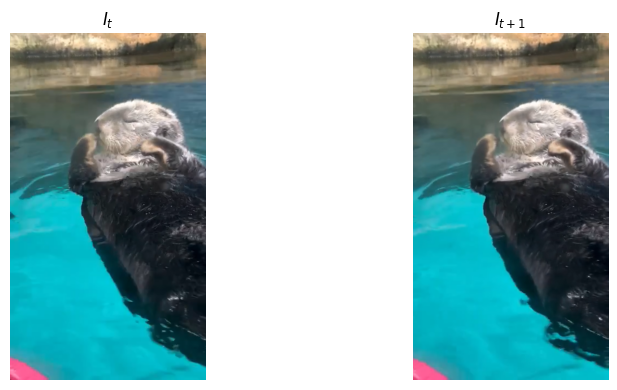

In [16]:
idx = len(frames) // 2

frame1_bgr = frames[idx]
frame2_bgr = frames[idx + 1]

frame1_gray = cv2.cvtColor(frame1_bgr, cv2.COLOR_BGR2GRAY)
frame2_gray = cv2.cvtColor(frame2_bgr, cv2.COLOR_BGR2GRAY)

frame1_rgb = cv2.cvtColor(frame1_bgr, cv2.COLOR_BGR2RGB)
frame2_rgb = cv2.cvtColor(frame2_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(frame1_rgb)
plt.title(r"$I_t$")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(frame2_rgb)
plt.title(r"$I_{t+1}$")
plt.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "q3_selected_frames.png", dpi=200)
plt.show()

**3a** - Brightness Constancy Assumption

The brightness constancy assumption states that the intensity of a moving point remains constant between two frames:

\[
I(x, y, t) = I(x + u, y + v, t + 1)
\]

This means that if a point moves from one position to another, its brightness value should stay the same.

In this part, we compare two frames and then deliberately violate this assumption by adding a brightness offset and Gaussian noise.

RMS difference between consecutive frames: 14.424874
RMS after brightness offset: 42.217937
RMS after Gaussian noise: 20.701525


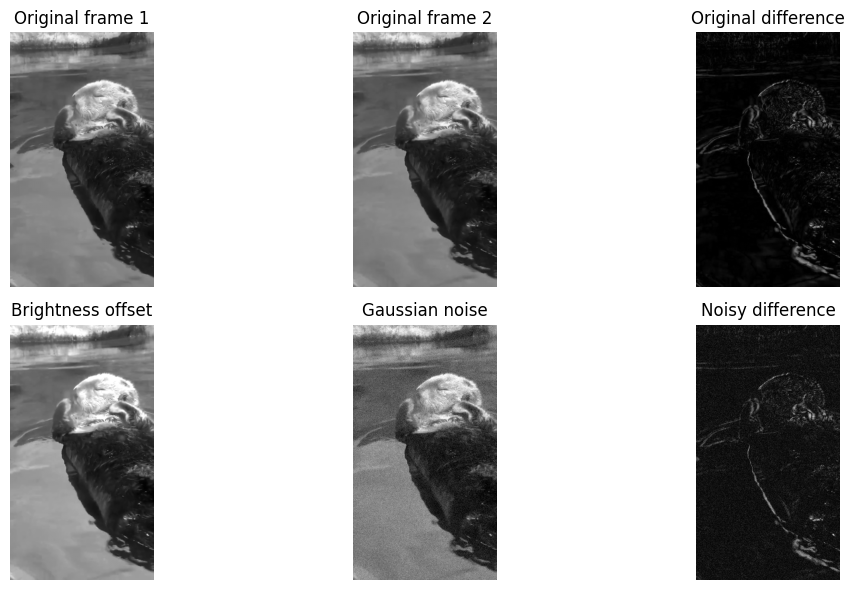

In [17]:
difference = frame2_gray.astype(np.float32) - frame1_gray.astype(np.float32)
rms_difference = np.sqrt(np.mean(difference ** 2))

print("RMS difference between consecutive frames:", rms_difference)

frame2_offset = np.clip(frame2_gray.astype(np.float32) + 40, 0, 255).astype(np.uint8)

noise = np.random.normal(0, 15, frame2_gray.shape)
frame2_noise = np.clip(frame2_gray.astype(np.float32) + noise, 0, 255).astype(np.uint8)

diff_offset = frame2_offset.astype(np.float32) - frame1_gray.astype(np.float32)
diff_noise = frame2_noise.astype(np.float32) - frame1_gray.astype(np.float32)

print("RMS after brightness offset:", np.sqrt(np.mean(diff_offset ** 2)))
print("RMS after Gaussian noise:", np.sqrt(np.mean(diff_noise ** 2)))

plt.figure(figsize=(12, 6))

plt.subplot(2, 3, 1)
plt.imshow(frame1_gray, cmap="gray")
plt.title("Original frame 1")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(frame2_gray, cmap="gray")
plt.title("Original frame 2")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(np.abs(difference), cmap="gray")
plt.title("Original difference")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(frame2_offset, cmap="gray")
plt.title("Brightness offset")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(frame2_noise, cmap="gray")
plt.title("Gaussian noise")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(np.abs(diff_noise), cmap="gray")
plt.title("Noisy difference")
plt.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "q3_brightness_violation.png", dpi=200)
plt.show()

### (3b) Lucas-Kanade

Lucas-Kanade resolves the aperture problem *locally*: it assumes all pixels within a small window around a point share the same flow vector $(u, v)$. This gives an overdetermined system that is solved in a least-squares sense. Crucially, it only works well at points where the gradient points in multiple directions, which is exactly what corners provide.

1. Detect corners to track using `cv2.goodFeaturesToTrack()`
2. Compute sparse flow using `cv2.calcOpticalFlowPyrLK()`
3. Visualize the flow vectors. Draw arrows from each original corner to its tracked position using `cv2.arrowedLine()`. Use green for tracked points, red for lost ones.
4. Sweep `winSize`. Repeat tracking with `winSize` $\in \{5, 15, 31, 51\}$ keeping `maxLevel=3`. What do you observe?

Why does Lucas-Kanade require corner-like points rather than arbitrary pixels?


 **3b** - Lucas-Kanade Sparse Optical Flow

The Lucas-Kanade method estimates optical flow only at selected feature points.  
First, good feature points are detected in the first frame. Then, their new positions are estimated in the next frame.

This is called sparse optical flow because motion is computed only for a limited number of points, not for every pixel.

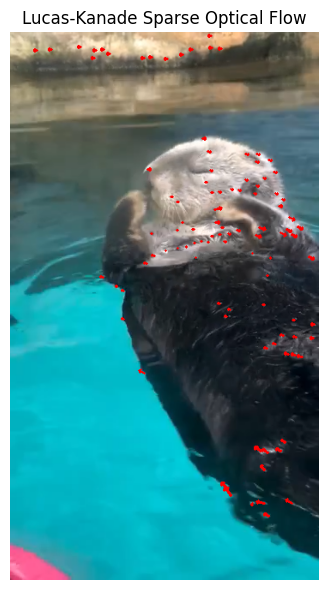

Mean displacement [dx, dy]: [0.14804329 0.20726131]
Mean displacement magnitude: 3.328681


In [18]:
p0 = cv2.goodFeaturesToTrack(
    frame1_gray,
    maxCorners=100,
    qualityLevel=0.01,
    minDistance=8,
    blockSize=7
)

p1, status, error = cv2.calcOpticalFlowPyrLK(
    frame1_gray,
    frame2_gray,
    p0,
    None,
    winSize=(21, 21),
    maxLevel=3,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
)

good_old = p0[status == 1]
good_new = p1[status == 1]

lk_visualization = frame1_rgb.copy()

for old, new in zip(good_old, good_new):
    x_old, y_old = old.ravel()
    x_new, y_new = new.ravel()
    cv2.arrowedLine(
        lk_visualization,
        (int(x_old), int(y_old)),
        (int(x_new), int(y_new)),
        (255, 0, 0),
        2,
        tipLength=0.3
    )

plt.figure(figsize=(8, 6))
plt.imshow(lk_visualization)
plt.title("Lucas-Kanade Sparse Optical Flow")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "q3_lucas_kanade.png", dpi=200)
plt.show()

displacements = good_new - good_old
mean_displacement = np.mean(displacements, axis=0)
mean_magnitude = np.mean(np.linalg.norm(displacements, axis=1))

print("Mean displacement [dx, dy]:", mean_displacement)
print("Mean displacement magnitude:", mean_magnitude)

### (3c) Farneback (Dense Optical Flow)

Dense methods compute a flow vector at every pixel, not just at detected corners. OpenCV's Farneback method is a polynomial expansion approach that approximates the neighbourhood of each pixel with a quadratic polynomial and finds the flow that best aligns the two polynomials.

1. Compute dense flow on your frame pair using `cv2.calcOpticalFlowFarneback()`
2. Vizualise as an HSV color wheel- this is the standard convention for dense flow visualization where hue encodes direction and saturation encodes magnitude.
3. Now examine the flow in static background regions: compute the mean magnitude `np.mean(np.sqrt(u**2 + v**2))` in a manually selected static region (e.g. a patch of background). Is it zero? Why not — and what does this residual flow in static regions tell you about the limitations of dense methods?

 **3c** - Farneback Dense Optical Flow

The Farneback method estimates dense optical flow.  
This means that it computes motion information for almost every pixel in the image.

In the HSV visualization, the color represents the motion direction, and the brightness represents the motion magnitude.

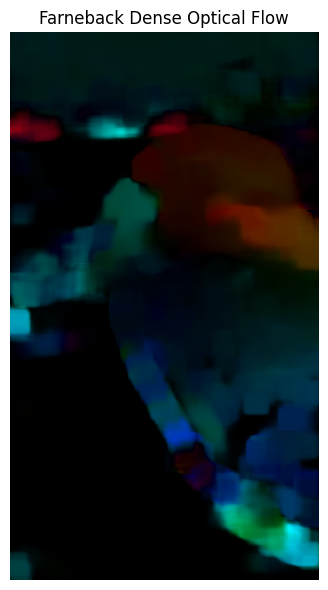

Mean flow magnitude: 2.3683937
Max flow magnitude: 19.60202


In [19]:
flow = cv2.calcOpticalFlowFarneback(
    frame1_gray,
    frame2_gray,
    None,
    pyr_scale=0.5,
    levels=3,
    winsize=25,
    iterations=3,
    poly_n=5,
    poly_sigma=1.2,
    flags=0
)

magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

hsv = np.zeros_like(frame1_bgr)
hsv[..., 0] = angle * 180 / np.pi / 2
hsv[..., 1] = 255
hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

farneback_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(farneback_rgb)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "q3_farneback.png", dpi=200)
plt.show()

print("Mean flow magnitude:", np.mean(magnitude))
print("Max flow magnitude:", np.max(magnitude))

**Conclusion**

The results show that optical flow can be used to estimate motion between two frames.  
Lucas-Kanade provides sparse motion vectors for selected feature points, while Farneback provides a dense motion field for almost every pixel.

The brightness constancy assumption is important for optical flow. When brightness changes or noise is added, this assumption is violated and the motion estimation becomes less reliable.